# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [4]:
# =====================================================================
# **2. Import Library**
# =====================================================================

# Library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np
import os

# Library untuk visualisasi data (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk preprocessing data dan standarisasi
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Memastikan output plot visualisasi muncul di dalam notebook
%matplotlib inline

print("[INFO] Semua library dasar untuk eksperimen Raka berhasil di-import!")

[INFO] Semua library dasar untuk eksperimen Raka berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:


# Memuat data train untuk proses analisis dan eksperimen awal
df_train = pd.read_csv('/content/train.csv')

# Menampilkan 5 baris pertama data untuk inspeksi awal
print("=== 5 Baris Pertama Dataset Train ===")
display(df_train.head())

# Menampilkan informasi dimensi data
print(f"\nJumlah baris data: {df_train.shape[0]}")
print(f"Jumlah kolom data: {df_train.shape[1]}")

=== 5 Baris Pertama Dataset Train ===


/tmp/ipykernel_640/1156540053.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('/content/train.csv')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good



Jumlah baris data: 100000
Jumlah kolom data: 28


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== Struktur dan Tipe Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan  

,Monthly_Inhand_Salary,Credit_Utilization_Ratio
count,84998.000000,100000.000000
mean,4194.170850,32.285173
std,3183.686167,5.116875
min,303.645417,20.000000
25%,1625.568229,28.052567
50%,3093.745000,32.305784
75%,5957.448333,36.496663
max,15204.633333,50.000000


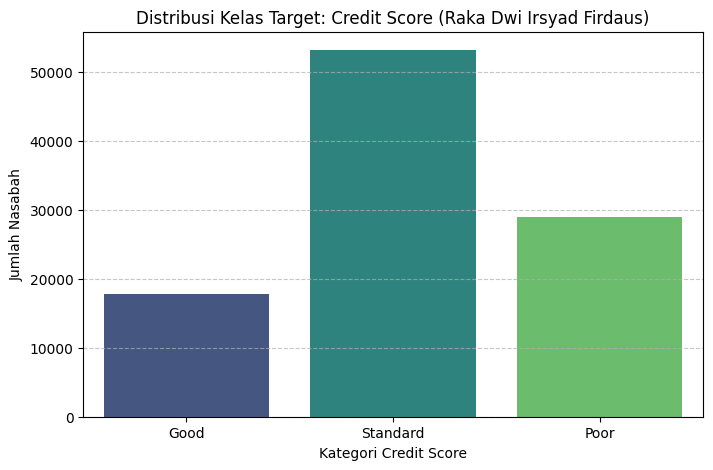


=== Jumlah Distribusi Kelas Target ===
Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


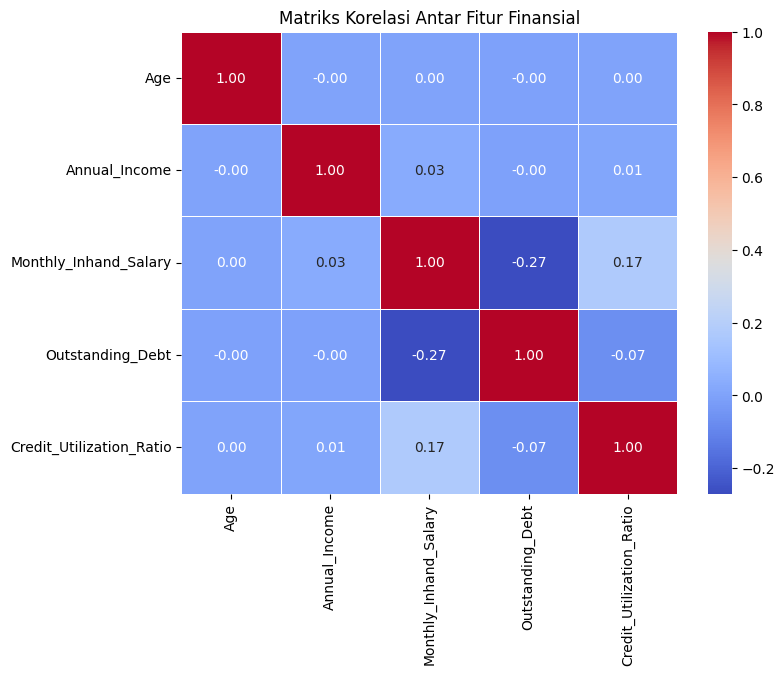

In [9]:
# 1. Memeriksa tipe data dan kondisi missing value secara umum
print("=== Struktur dan Tipe Data ===")
print(df_train.info())

# 2. Statistik deskriptif untuk fitur numerik dasar
print("\n=== Statistik Deskriptif Fitur Numerik ===")
display(df_train[['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt', 'Credit_Utilization_Ratio']].describe())

# 3. Visualisasi Distribusi Variabel Target (Credit Score)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='Credit_Score', hue='Credit_Score', palette='viridis', legend=False)
plt.title('Distribusi Kelas Target: Credit Score (Raka Dwi Irsyad Firdaus)')
plt.xlabel('Kategori Credit Score')
plt.ylabel('Jumlah Nasabah')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Menampilkan jumlah persis dari masing-masing kelas
print("\n=== Jumlah Distribusi Kelas Target ===")
print(df_train['Credit_Score'].value_counts())

# Sebelum cek korelasi, kita bersihkan dulu karakter '_' agar fitur bisa dibaca sebagai numerik
df_eda = df_train.copy()
df_eda['Age'] = pd.to_numeric(df_eda['Age'].astype(str).str.replace('_', ''), errors='coerce')
df_eda['Annual_Income'] = pd.to_numeric(df_eda['Annual_Income'].astype(str).str.replace('_', ''), errors='coerce')
df_eda['Outstanding_Debt'] = pd.to_numeric(df_eda['Outstanding_Debt'].astype(str).str.replace('_', ''), errors='coerce')

# Pilih subset fitur numerik penting
eda_features = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt', 'Credit_Utilization_Ratio']

# Plot Heatmap Korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(df_eda[eda_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Antar Fitur Finansial')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [11]:
# --- 1. Memuat Dataset Mentah dari Langkah Sebelumnya ---
# df_train diambil dari hasil load data di bagian 3
df_prepro = df_train.copy()
print(f"Dimensi data awal sebelum diproses: {df_prepro.shape}")


# --- 2. Menghapus Data Duplikat ---
df_prepro = df_prepro.drop_duplicates()
print(f"Dimensi data setelah menghapus duplikat: {df_prepro.shape}")


# --- 3. Penanganan Karakter Kotor & Konversi Tipe Data ---
# Berdasarkan karakteristik dataset Credit Score, kolom 'Age', 'Annual_Income', dan 'Outstanding_Debt'
# sering kali mengandung karakter string kotor seperti '_' yang harus dibersihkan.
df_prepro['Age'] = df_prepro['Age'].astype(str).str.replace('_', '')
df_prepro['Age'] = pd.to_numeric(df_prepro['Age'], errors='coerce')

df_prepro['Annual_Income'] = df_prepro['Annual_Income'].astype(str).str.replace('_', '')
df_prepro['Annual_Income'] = pd.to_numeric(df_prepro['Annual_Income'], errors='coerce')

df_prepro['Outstanding_Debt'] = df_prepro['Outstanding_Debt'].astype(str).str.replace('_', '')
df_prepro['Outstanding_Debt'] = pd.to_numeric(df_prepro['Outstanding_Debt'], errors='coerce')


# --- 4. Menghapus atau Menangani Data Kosong (Missing Values) ---
# Mengisi missing value pada fitur-fitur numerik utama menggunakan nilai Median
num_cols = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt', 'Credit_Utilization_Ratio']
for col in num_cols:
    median_value = df_prepro[col].median()
    df_prepro[col] = df_prepro[col].fillna(median_value)

# Memastikan target variabel 'Credit_Score' tidak mengandung nilai kosong
df_prepro = df_prepro.dropna(subset=['Credit_Score'])
print("Penanganan missing values (imputasi median) selesai dilakukan.")


# --- 5. Pemilihan Fitur (Feature Selection) ---
# Memilih subset fitur finansial dan demografi yang paling relevan untuk permodelan
selected_features = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_Score']
df_features = df_prepro[selected_features].copy()


# --- 6. Encoding Data Kategorikal (Variabel Target) ---
# Mengubah kelas target teks ('Good', 'Standard', 'Poor') menjadi representasi angka (0, 1, 2)
le_target = LabelEncoder()
df_features['Credit_Score'] = le_target.fit_transform(df_features['Credit_Score'])
print("Hasil encoding target Credit_Score:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))


# --- 7. Normalisasi atau Standarisasi Fitur Numerik ---
# Melakukan standarisasi (Z-score scaling) agar rentang nilai fitur seragam sebelum masuk ke model
scaler = StandardScaler()
df_features[num_cols] = scaler.fit_transform(df_features[num_cols])
print("Proses standarisasi fitur numerik selesai.")


# --- 8. Menyimpan Dataset Hasil Preprocessing ---
# Menyimpan file ke folder sesuai standarisasi struktur proyek Dicoding MLOps
output_dir = 'namadataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'credit_score_clean.csv')

df_features.to_csv(output_path, index=False)
print(f"\n[SUCCESS] Preprocessing Selesai! Dataset bersih disimpan di: '{output_path}'")

Dimensi data awal sebelum diproses: (100000, 28)
Dimensi data setelah menghapus duplikat: (100000, 28)
Penanganan missing values (imputasi median) selesai dilakukan.
Hasil encoding target Credit_Score: {'Good': np.int64(0), 'Poor': np.int64(1), 'Standard': np.int64(2)}
Proses standarisasi fitur numerik selesai.

[SUCCESS] Preprocessing Selesai! Dataset bersih disimpan di: 'namadataset_preprocessing/credit_score_clean.csv'
